In [1]:
import subprocess
import sys
import re
import os
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import astropy.units as u
from astropy.constants import G
from numpy import pi
import spacehub_calc as sc
import matplotlib.animation as animation
import time
import itertools
from tqdm.notebook import tqdm
from scipy.integrate import quad

Initial Conditions (Change to match code):

In [2]:
#These match the code currently (1/22)
#TODO update if changed in SpaceHub
rho = 1e-15 * u.kg / u.cm / u.cm / u.cm
cs = 50 * u.km / u.s
m0, m1 = 1*u.Msun, 1*u.Msun
a0 = 1*u.AU
af = 0.9 * u.AU

Derivation of semi-major axis damping time $t_f(a_0, a_f)$ for Bondi-Hoyle-Littleton drag

$$F_{BH} = \frac{Am^2}{B+v^2}, \quad A=4\pi G\rho,\quad B=c_s^2$$

$$E = \frac{-Gm^2}{2a}; \quad v=\sqrt{\frac{GM}{2a}}$$

$$\frac{dE}{dt} = \frac{dE}{da}\frac{da}{dt} = \frac{Gm^2 }{2a^2}\frac{da}{dt}$$

$$\frac{dE}{dt}=-2(F\cdot v) = \frac{4\pi(Gm)^2\rho}{c_s^2+\frac{Gm}{2a}}\sqrt{\frac{Gm}{2a}}$$

$$\frac{da}{dt}=\frac{dE}{dt}\frac{da}{dE}=\frac{-16\pi G \rho a^2 \sqrt{Gm/2a}}{c_s^2+\frac{Gm}{2a}}$$

$$\frac{da}{dt}=\frac{-32\pi G \rho a^{5/2}}{2ac_s^2+Gm}\sqrt{\frac{Gm}{2}}$$

$$t_f = \frac{\sqrt{2}}{32\pi G \rho \sqrt{Gm}}  \int_{a_0}^{a_f}\frac{2ac_s^2+Gm}{a^{5/2}}da$$


In [3]:
#Implementation of the above
def sma_damping_BHL_correct(a0, af):
    # Derived from energy dissipation assuming "idealized" circular orbit with equal masses
    m = m0  # Assuming m0 = m1
    
    
    def integrand_eval(a):
        return (6*cs**2 * a + G*m) / (3 * 2**(7/2) * pi * G**(3/2) * m**(1/2) * rho * a**(3/2))
    
    tf = (integrand_eval(af) - integrand_eval(a0))
    return tf.decompose()

tf_bhl_analytical = sma_damping_BHL_correct(a0=a0, af=af).to(u.yr)
tf_bhl_analytical

<Quantity 962.60219866 yr>

Derivation of semi-major axis damping time $t_f(a_0, a_f)$ for Dynamical Friction

$$\vec{F}_{dyn} = -\mathcal{I}\frac{4\pi (Gm)^2 \rho}{v^3}\vec{v}$$


$$\mathcal{I} = \begin{cases} \frac{1}{2}\ln\left(\frac{1+\mathcal{M}}{1-\mathcal{M}}\right) - \mathcal{M}, & \mathcal{M} < 1 \text{ (subsonic)} \\ \frac{1}{2}\ln\left(1 - \frac{1}{\mathcal{M}^2}\right) + \Lambda, & \mathcal{M} > 1 \text{ (supersonic)} \end{cases}$$


$$|F_{dyn}| = \mathcal{I}\frac{4\pi G^2 m^2 \rho}{v^2}$$

$$\frac{dE}{dt} = -2|F_{dyn}| \cdot v = -\frac{8\pi \mathcal{I} G^2 m^2 \rho}{v}$$

Using $\frac{dE}{da} = \frac{Gm^2}{2a^2}$:

$$\frac{da}{dt} = \frac{dE/dt}{dE/da} = -\frac{16\pi \mathcal{I} G \rho a^2}{v} = -16\pi \mathcal{I} \rho \sqrt{\frac{2G}{m}} a^{5/2}$$

$$t_f = -\int_{a_0}^{a_f}\frac{\sqrt{m}}{-16\pi\mathcal{I}\sqrt{2G}\rho a^{5/2}} da$$



**The Approximate Integrals below only really work if the objects spend the majority of their time in one of the extreme regimes (highly sub or super sonic)** 

---

### Supersonic Regime 

For $\mathcal{M} \gg 1$: $\mathcal{I}_{sup} \approx \Lambda$ (constant)

$$\frac{da}{dt} = -16\pi \Lambda \rho \sqrt{\frac{2G}{m}} a^{5/2}$$


$$\int_{a_0}^{a_f} a^{-5/2} da = -16\pi \Lambda \rho \sqrt{\frac{2G}{m}} \int_0^{t_f} dt$$

$$\boxed{t_{f,sup} = \frac{\sqrt{m}}{24\sqrt{2}\pi \Lambda \rho \sqrt{G}}\left(\frac{1}{a_f^{3/2}} - \frac{1}{a_0^{3/2}}\right)}$$

---

### Subsonic Regime

For $\mathcal{M} \ll 1$, Taylor:
$$\ln\left(\frac{1+\mathcal{M}}{1-\mathcal{M}}\right) \approx 2\mathcal{M} + \frac{2\mathcal{M}^3}{3} + \mathcal{O}^+$$

$$\mathcal{I}_{sub} \approx \frac{\mathcal{M}^3}{3} = \frac{1}{3}\left(\frac{Gm}{2ac_s^2}\right)^{3/2}$$


$$\frac{da}{dt} = -16\pi \cdot \frac{(Gm)^{3/2}}{3(2a)^{3/2}c_s^3} \cdot \rho \sqrt{\frac{2G}{m}} \cdot a^{5/2} = -\frac{16\pi \rho G^2 m}{3\sqrt{2}c_s^3} a$$


$$\int_{a_0}^{a_f} \frac{da}{a} = -\frac{16\pi \rho G^2 m}{3\sqrt{2}c_s^3} t_f$$

$$\boxed{t_{f,sub} = \frac{3\sqrt{2}c_s^3}{16\pi \rho G^2 m}\ln\left(\frac{a_0}{a_f}\right)}$$

---


$$t_f = t_{sub}(a_0 \to a_T) + t_{sup}(a_T \to a_f)$$

$$\boxed{t_f = \frac{3\sqrt{2}c_s^3}{16\pi \rho G^2 m}\ln\left(\frac{a_0 \cdot 2c_s^2}{Gm}\right) + \frac{\sqrt{m}}{24\sqrt{2}\pi \Lambda \rho \sqrt{G}}\left(\frac{1}{a_f^{3/2}} - \frac{2^{3/2}c_s^3}{(Gm)^{3/2}}\right)}$$

---

**Assuming:**
1. $m_1 = m_2 \equiv m$
2. Circular orbit 
3. Subsonic approx  $\mathcal{I} \approx \mathcal{M}^3/3$
4. Supersonic approx: $\mathcal{I} \approx \Lambda$

In [4]:
lnR = 3  # matches SpaceHub

def sma_damping_dyn_general(a0, af, m, Lambda=3):
    
    # Calculate transition semi-major axis and Mach numbers
    a_T = (G * m / (2 * cs**2)).decompose()
    M0 = (np.sqrt(G * m / (2 * a0)) / cs).decompose().value
    Mf = (np.sqrt(G * m / (2 * af)) / cs).decompose().value
    
    print(f"Transition semi-major axis a_T = {a_T.to(u.AU):.4f}")
    print(f"Initial Mach number M_0 = {M0:.4f}")
    print(f"Final Mach number M_f = {Mf:.4f}")
    
    if M0 < 1 and Mf < 1:
        #print("SUBSONIC only")
        prefactor = 3 * np.sqrt(2) * cs**3 / (16 * pi * rhodyn * G**2 * m)
        return (prefactor * np.log(a0 / af)).decompose()
    elif M0 > 1 and Mf > 1:
        #print("SUPER SONIC only")
        prefactor = np.sqrt(m) / (24 * np.sqrt(2) * pi * Lambda * rhodyn * np.sqrt(G))
        return (prefactor * (1/af**(3/2) - 1/a0**(3/2))).decompose()
    elif M0 < 1 and Mf > 1:
        print("subsonic -> supersonic")
        # a0 -> a_T
        prefactor_sub = 3 * np.sqrt(2) * cs**3 / (16 * pi * rhodyn * G**2 * m)
        t_sub = (prefactor_sub * np.log(a0 / a_T)).decompose()
        # a_T -> af
        prefactor_sup = np.sqrt(m) / (24 * np.sqrt(2) * pi * Lambda * rhodyn * np.sqrt(G))
        t_sup = (prefactor_sup * (1/af**(3/2) - 1/a_T**(3/2))).decompose()
        return t_sub + t_sup
    else:
        raise ValueError("Semi-major axis increasing!")


rhodyn = 1e-15 * u.kg / u.cm / u.cm / u.cm
cs = 50 * u.km / u.s
m0dyn, m1dyn = 5*u.Msun, 5*u.Msun
a0dyn = 2.5*u.AU
afdyn = 0.4 * u.AU
m = m0dyn  # Using m0 = m1 = 5 Msun from the setup

tf_dyn_analytical = sma_damping_dyn_general(a0dyn, afdyn, m, Lambda=lnR).to(u.yr)
print(f"\nAnalytical damping time ({a0dyn.value:.1f} -> {afdyn.value:.1f}) t_f = {tf_dyn_analytical.to(u.yr):.2f}")

Transition semi-major axis a_T = 0.8871 AU
Initial Mach number M_0 = 0.5957
Final Mach number M_f = 1.4892
subsonic -> supersonic

Analytical damping time (2.5 -> 0.4) t_f = 9642.21 yr


In [5]:
# Numerical integration method
# Matches Yihan's connect function that I recycled

def I_subsonic(M):
    """(1/2)ln((1+M)/(1-M)) - M"""
    if M <= 0:
        return 0.0
    if M >= 1:
        raise ValueError("M>=1 should not be passed to subsonic")
    return 0.5 * np.log((1 + M) / (1 - M)) - M

def I_supersonic(M, Lambda=3):
    """(1/2)ln(1 - 1/M^2) + Lambda"""
    if M <= 1:
        raise ValueError("M<=1 should not be passed to supersonic")
    return 0.5 * np.log(1 - 1/(M*M)) + Lambda

def I_full_domain(M, Lambda=3):
    """
    replica of Yihan's implementation incl. connect function
    """
    # Transition region parameters (same as drag-forces.hpp)
    logR = Lambda
    eps = 1 / np.exp(2.0 * logR / 3.0)
    connect_lowerbound = 1 - eps  # Lower bound of connect zone
    connect_upperbound = 1 + eps  # Upper bound of connect zone
    
    
    y1 = I_subsonic(connect_lowerbound)
    y2 = I_supersonic(connect_upperbound, Lambda)
    
    # ==============Hermite interpolation stuff==============
    def dI_sub(M):
        return 1/(1 - M*M) - 1
    def dI_sup(M):
        return 1/(M*(M*M - 1))
    
    k1 = dI_sub(connect_lowerbound)
    k2 = dI_sup(connect_upperbound)
    
    
    a = k1 * (connect_upperbound - connect_lowerbound) - (y2 - y1)
    b = -k2 * (connect_upperbound - connect_lowerbound) + (y2 - y1)
    # ============= Back to reality ==================
    def connect(M):
        t = (M - connect_lowerbound) / (connect_upperbound - connect_lowerbound)
        return (1 - t) * y1 + y2 * t + (1 - t) * t * (t * b + (1 - t) * a)
    
    # Low Mach asymptotic approx as per paper
    if M <= 0.1:
        return M**3 / 3.0
    elif M < connect_lowerbound:
        return I_subsonic(M)
    elif M <= connect_upperbound:
        return connect(M)
    else:
        return I_supersonic(M, Lambda)

def dadt_numerical(a, m, rho, cs, Lambda=3):
    """
    Use previously derived da/dt = -16π I(M) ρ √(2G/m) a^(5/2)
    
    """
    # Get values without units for numerical computation
    G_val = G.to(u.AU**3 / u.Msun / u.yr**2).value
    m_val = m.to(u.Msun).value
    rho_val = rho.to(u.Msun / u.AU**3).value
    cs_val = cs.to(u.AU / u.yr).value
    
    a_val = a # float in AU already
    
    
    v = np.sqrt(G_val * m_val / (2 * a_val))
    M = (v / cs_val)
    
    
    I = I_full_domain(M, Lambda)
    
    
    prefactor = -16 * np.pi * rho_val * np.sqrt(2 * G_val / m_val)
    da_dt = prefactor * I * a_val**(5/2)
    
    return da_dt

def sma_damping_dyn_numerical(a0, af, m, rho, cs, Lambda=3):

    a0_val = a0.to(u.AU).value
    af_val = af.to(u.AU).value
    
    def integrand(a):
        dadt = dadt_numerical(a, m, rho, cs, Lambda)
        if dadt == 0:
            raise ValueError("da/dt=0, no integration") #happened at least once
        return 1.0 / dadt  # dt/da
    
    
    result, error = quad(integrand, a0_val, af_val) #Why is it called quad? -A something to do with FORTRAN
    tf = result * u.yr #put units back

    return tf


print("=== Numerical Integration ===\n")

# Calculate Mach numbers and transition SMA inline
M0_num = (np.sqrt(G * m / (2 * a0dyn)) / cs).decompose().value
Mf_num = (np.sqrt(G * m / (2 * afdyn)) / cs).decompose().value
a_transition_num = (G * m / (2 * cs**2)).decompose()
M_transition = 1.0 #For debug

print(f"ICS: a0 = {a0dyn}: M = {M0_num:.4f}, I_full_domain = {I_full_domain(M0_num, lnR):.6f}, asymptotic I = {M0_num**3/3:.6f}")
print(f"At transition point a = {a_transition_num.to(u.AU):.4f}: M = {M_transition:.4f}, I_full_domain = {I_full_domain(M_transition, lnR):.6f}")
print(f"final: a_f = {afdyn}: M = {Mf_num:.4f}, I_full_domain = {I_full_domain(Mf_num, lnR):.6f}, asymptotic I = {lnR:.6f}")

tf_dyn_numerical_int = sma_damping_dyn_numerical(a0dyn, afdyn, m, rhodyn, cs, lnR)
print(f"\nNumerical t_f = {tf_dyn_numerical_int.to(u.yr):.2f}")
print(f"Analytical approximation damping time t_f = {tf_dyn_analytical.to(u.yr):.2f}")
print(f"Ratio (numerical_int / asymptotic) = {tf_dyn_numerical_int.to(u.yr).value / tf_dyn_analytical.to(u.yr).value:.4f}")

=== Numerical Integration ===

ICS: a0 = 2.5 AU: M = 0.5957, I_full_domain = 0.090752, asymptotic I = 0.070461
At transition point a = 0.8871 AU: M = 1.0000, I_full_domain = 1.346747
final: a_f = 0.4 AU: M = 1.4892, I_full_domain = 2.700269, asymptotic I = 3.000000

Numerical t_f = 8599.22 yr
Analytical approximation damping time t_f = 9642.21 yr
Ratio (numerical_int / asymptotic) = 0.8918


Derivation of semi-major axis damping time $t_f(a_0, a_f)$ for Aerodynamic Drag


$$F_{aero} = -\pi R^2 \rho v_{rel} \vec{v}_{rel}$$

$$|F_{aero}| = \pi R^2 \rho v^2$$


$$\frac{dE}{dt} = -2|F_{aero}| \cdot v = -2\pi R^2 \rho v^3$$

Substituting $v = \sqrt{Gm/2a}$:
$$\frac{dE}{dt} = -2\pi R^2 \rho \left(\frac{Gm}{2a}\right)^{3/2}$$

Using $\frac{dE}{da} = \frac{Gm^2}{2a^2}$:

$$\frac{da}{dt} = \frac{dE/dt}{dE/da} = \frac{-2\pi R^2 \rho (Gm)^{3/2}/(2a)^{3/2}}{Gm^2/(2a^2)} = -\frac{4\pi 2^{3/2} R^2 \rho (Gm)^{3/2} a^{1/2}}{Gm^2}$$

$$\frac{da}{dt} = \frac{-2\pi R^2 \rho \sqrt{G}a^{1/2}}{\sqrt{2m}}$$

$$dt = \frac{\sqrt{2m}}{-2\pi R^2 \rho \sqrt{G}a^{1/2}}da$$

$$t_f = \left[\frac{\sqrt{2ma}}{\pi\sqrt{G}R^2\rho}\right]^{a_f}_{a_0}$$




In [6]:
def sma_damping_aero(a0, af, m, R):
    """
    Aerodynamic drag damping time for circular orbit with m1=m2, R1=R2
    """
    def integrand(a, m, R):
        return -np.sqrt(2*m*a)/(pi * np.sqrt(G)*R*R*rho_aero)
    
    tf = integrand(af, m, R) - integrand(a0, m, R)
    return tf.decompose()


rho_aero = 1e-12 * u.kg / u.cm / u.cm / u.cm
cs_aero = 50 * u.km / u.s
m0_aero, m1_aero = 1*u.Msun, 1*u.Msun
a0_aero = 1*u.AU
af_aero = 0.9 * u.AU

R_aero = 5 * u.Rsun 

tf_aero_analytical = sma_damping_aero(a0_aero, af_aero, m0_aero, R_aero).to(u.yr)
print(f"\nAnalytical damping time t_f = {tf_aero_analytical.to(u.yr):.1f}")


Analytical damping time t_f = 4038.8 yr


In [7]:
#Run simulation cell
if False:
    output = "test/nick_test/AnalyticalTests/FBH_damptime_circ.dat"
    compilecmd = "g++ -std=c++17 -O3 -pthread test/nick_test/KeplerSimple.cpp -o test/nick_test/KeplerSimple"
    runcmd = f"test/nick_test/KeplerSimple -rtype bh -m1 {m0.value} -m2 {m1.value} -sma {a0} -stop {(1.5*(2*np.pi)*tf_bhl_analytical.to(u.yr).value):.1f} -out {output} "
    clearcmd = "rm test/nick_test/AnalyticalTests/FBH_damptime.dat"

    if True:
        print(runcmd)
    try:
        clearstd = subprocess.run(clearcmd, shell=True, capture_output=True, text=True, timeout=15)
    except Exception as e:
        print("not cleared")
    compstd = subprocess.run(compilecmd, shell=True, capture_output=True, text=True, timeout=60)
    runstd = subprocess.run(runcmd, shell=True, capture_output=True, text=True, timeout=180)

    if runstd.returncode != 0:
        print(runstd.stderr)
    print(runstd.stdout)


In [8]:
orb_fbh = sc.TwoBodyOrbit("test/nick_test/AnalyticalTests/FBH_damptime_circ.dat")
tf_numerical_fbh = orb_fbh.find_crossing('a', 0.9, years=True)
#fig, axs = orb.plot_keplerian_evolution(plots=('a', 'e', 'i', 'R'), ylim=False)
#plt.show()

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within inf of constant (maximum - minimum)
Done


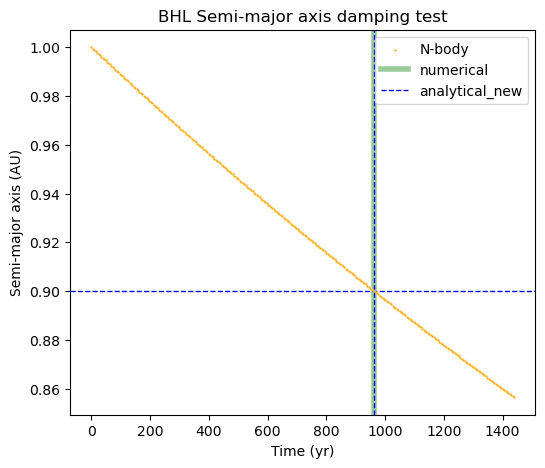

In [9]:
#Visualize the test
fig, ax =  plt.subplots(figsize=(6,5))
sns.scatterplot(x=orb_fbh.years, y=orb_fbh.semiMajorAxis, s=3, ax=ax, color="orange", label="N-body", zorder=5)

#ax.axvline(x=tf_numericalhc[0], color="blue", alpha=0.8, linestyle=":", label="numerical-hc")
ax.axvline(x=tf_numerical_fbh[0], color="green", alpha=0.4, linestyle="-", lw=4, label="numerical")
ax.axvline(x=tf_bhl_analytical.value, color="blue", alpha=1, linestyle="--", lw=1, label="analytical_new", zorder=4)
ax.axhline(y=af.to(u.AU).value, color="blue", alpha=1, linestyle="--", lw=1, zorder=4)
ax.set_ylabel("Semi-major axis (AU)")
ax.set_xlabel("Time (yr)")
ax.set_title("BHL Semi-major axis damping test")
ax.legend()

In [10]:
orb_aero = sc.TwoBodyOrbit("test/nick_test/AnalyticalTests/Circular-AeroTest.dat")
tf_numerical_aero = orb_aero.find_crossing('a', 0.9, years=True)
#fig, axs = orb.plot_keplerian_evolution(plots=('a', 'e', 'i', 'R'), ylim=False)
#plt.show()

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within inf of constant (maximum - minimum)
Done


Ratio of numerical:analytical results: 0.9999926014142049


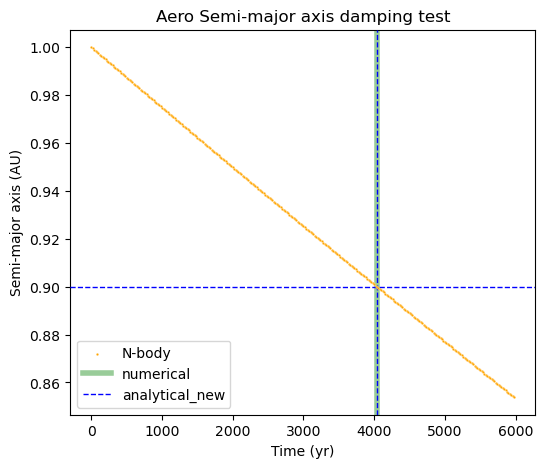

In [11]:
#Visualize the test
fig, ax =  plt.subplots(figsize=(6,5))
sns.scatterplot(x=orb_aero.years, y=orb_aero.semiMajorAxis, s=3, ax=ax, color="orange", label="N-body", zorder=5)

#ax.axvline(x=tf_numericalhc[0], color="blue", alpha=0.8, linestyle=":", label="numerical-hc")
ax.axvline(x=tf_numerical_aero[0], color="green", alpha=0.4, linestyle="-", lw=4, label="numerical")
ax.axvline(x=tf_aero_analytical.value, color="blue", alpha=1, linestyle="--", lw=1, label="analytical_new", zorder=4)
ax.axhline(y=af_aero.to(u.AU).value, color="blue", alpha=1, linestyle="--", lw=1, zorder=4)
ax.set_ylabel("Semi-major axis (AU)")
ax.set_xlabel("Time (yr)")
ax.set_title("Aero Semi-major axis damping test")
ax.legend()

print(f"Ratio of numerical:analytical results: {tf_numerical_aero[0]/tf_aero_analytical.value}")

In [12]:
orbdyn = sc.TwoBodyOrbit("test/nick_test/AnalyticalTests/Circular-Dyntest.dat", mute=True)
tf_numerical_dyn = orbdyn.find_crossing('a', 0.4, years=True)


Calculated c0 values are within inf of constant (maximum - minimum)


N-body simulation crossing time: 8646.54 yr
Semi-analytical/Num. Integration: 8599.22 yr
Analytical/Asymptotic approx:       9642.21 yr

Ratio (N-body / numerical_int): 1.0055
Ratio (N-body / asymptotic):    0.8967


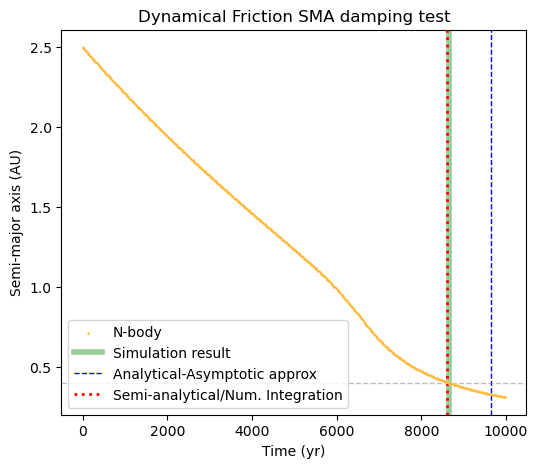

In [13]:
#Visualize the test
fig, ax =  plt.subplots(figsize=(6,5))
sns.scatterplot(x=orbdyn.years, y=orbdyn.semiMajorAxis, s=3, ax=ax, color="orange", label="N-body", zorder=5)

ax.axvline(x=tf_numerical_dyn[0], color="green", alpha=0.4, linestyle="-", lw=4, label="Simulation result")
ax.axvline(x=tf_dyn_analytical.value, color="blue", alpha=1, linestyle="--", lw=1, label="Analytical-Asymptotic approx", zorder=4)
ax.axvline(x=tf_dyn_numerical_int.to(u.yr).value, color="red", alpha=1, linestyle=":", lw=2, label="Semi-analytical/Num. Integration", zorder=4)
ax.axhline(y=afdyn.to(u.AU).value, color="gray", alpha=0.5, linestyle="--", lw=1, zorder=4)
ax.set_ylabel("Semi-major axis (AU)")
ax.set_xlabel("Time (yr)")
ax.set_title("Dynamical Friction SMA damping test")
ax.legend()

print(f"N-body simulation crossing time: {tf_numerical_dyn[0]:.2f} yr")
print(f"Semi-analytical/Num. Integration: {tf_dyn_numerical_int.to(u.yr).value:.2f} yr")
print(f"Analytical/Asymptotic approx:       {tf_dyn_analytical.to(u.yr).value:.2f} yr")
print(f"\nRatio (N-body / numerical_int): {tf_numerical_dyn[0]/tf_dyn_numerical_int.to(u.yr).value:.4f}")
print(f"Ratio (N-body / asymptotic):    {tf_numerical_dyn[0]/tf_dyn_analytical.value:.4f}")